# Fusión multisensor a nivel parcela y spatial K-fold

Este notebook responde una pregunta concreta: dado un banco de embeddings
AlphaEarth de 64 dimensiones cacheado localmente, más etiquetas reales
de PASTIS-R por píxel, ¿cómo se caracteriza el embedding, qué tan
estable es entre años, cómo se compara contra features espectro-
temporales hechas a mano, cómo se divide en folds espaciales sin fuga
de información, y cómo se ajusta un scaler reutilizable que respete
esa división?

El bloque AlphaEarth es la columna semántica de la matriz de fusión
multisensor. La matriz completa, cuando todas las fuentes externas
están disponibles, combina: embeddings AlphaEarth (64), índices
espectrales por estadístico (85), backscatter Sentinel-1 VV/VH (10),
terreno SRTM (3), clima ERA5 mensual (24) y descriptores geométricos
de la parcela (3) — total 189 columnas. Aquí ejecutamos el bloque
AlphaEarth con datos reales y mostramos la composición canónica de
los otros bloques a través de las constantes exportadas por el
módulo de fusión.

## Requisitos para ejecución end-to-end

- `poetry install --with ml,dev,test,geo` ejecutado.
- Cache AlphaEarth en `data/cache/gee/alphaearth_at_pastis_fr_2019_6000.parquet`
  (6000 puntos x 64 dimensiones, generado por sampling cacheado de
  Earth Engine en una US anterior). Si no existe, el notebook simula
  el banco con un generador determinista equivalente y continúa la
  ejecución.
- Cache de estabilidad inter-anual `data/cache/gee/alphaearth_at_italia_stab_{2022..2025}_500.parquet`
  (opcional, 500 puntos x 4 años; si no existen, sección 3 se omite
  con un mensaje informativo).
- Subset spectral-temporal `data/test_fixtures/feature_selection_subset.parquet`
  (opcional, para la comparativa indicativa de sección 4; si no
  existe, esa sección se omite).
- Dataset PASTIS-R en `data/PASTIS-R/` para las etiquetas por píxel.
  Si no está presente, la sección de etiquetas degrada a fixture
  sintética sin romper el flujo.

Secciones:

1. Setup y carga del banco AlphaEarth + etiquetas reales
2. Caracterización diagnóstica del bloque AlphaEarth (rango, norm L2, sparsity, distribución por dim)
3. Estabilidad inter-anual del embedding (2022-2025 Italia)
4. Comparativa indicativa AE 64-dim vs spectral-temporal 187-dim
5. Composición canónica de la matriz de fusión (189 columnas)
6. Agregación a nivel parcela y UMAP por clase y por grupo agronómico
7. Spatial K-fold con H3 + KMeans + buffer de exclusión
8. Scaler entrenado solo sobre train (sin fuga de información)
9. Selección y normalización sobre el bloque AlphaEarth
10. Persistencia de outputs consumibles (pixel-level + parcel-level + manifest)
11. Conclusiones


## 1. Setup y carga del banco AlphaEarth con etiquetas reales

In [1]:
from __future__ import annotations

import os
os.environ.setdefault('MPLBACKEND', 'Agg')

import json
import sys
import warnings
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import structlog
from IPython.display import Image, Markdown, display

from ml.utils.notebook_setup import find_repo_root

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from ml.features import (
    AE_COLS,
    BLOCK_NAMES,
    EXPECTED_COL_COUNT_NO_FARSLIP,
    EXPECTED_COL_COUNT_WITH_FARSLIP,
    FUSION_STATS,
    INDEX_NAMES,
    anova_f_select,
    apply_variance_threshold,
    drop_correlated_features,
    fit_pca,
    fit_scaler_on_train,
    fit_umap_2d,
    make_preprocessor,
    select_normalizer,
)
from ml.features.spatial_split import build_spatial_kfold
from ml.ingest.pastis_loader import (
    PASTIS_R_CLASSES,
    PASTIS_R_GROUPINGS,
    pastis_pixel_labels,
)

%load_ext autoreload
%autoreload 2

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
warnings.filterwarnings('ignore', category=UserWarning)

log = structlog.get_logger('fe_fusion')

REPORTS_DIR = REPO_ROOT / 'reports' / 'feature_fusion'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

AE_PARQUET = REPO_ROOT / 'data' / 'cache' / 'gee' / 'alphaearth_at_pastis_fr_2019_6000.parquet'
PASTIS_ROOT = REPO_ROOT / 'data' / 'PASTIS-R'
STAB_PARQUETS = {
    yr: REPO_ROOT / 'data' / 'cache' / 'gee' / f'alphaearth_at_italia_stab_{yr}_{yr}_500.parquet'
    for yr in (2022, 2023, 2024, 2025)
}
ST_SUBSET = REPO_ROOT / 'data' / 'test_fixtures' / 'feature_selection_subset.parquet'
display(Markdown(
    f'**Cache AlphaEarth PASTIS-FR**: `{AE_PARQUET.relative_to(REPO_ROOT)}` (existe: `{AE_PARQUET.exists()}`)  \n'
    f'**PASTIS-R root**: `{PASTIS_ROOT.relative_to(REPO_ROOT)}` (existe: `{PASTIS_ROOT.exists()}`)  \n'
    f'**Cache estabilidad inter-anual Italia**: '
    f'`{sum(p.exists() for p in STAB_PARQUETS.values())}/4` años disponibles  \n'
    f'**Subset spectral-temporal (notebook anterior)**: `{ST_SUBSET.relative_to(REPO_ROOT)}` '
    f'(existe: `{ST_SUBSET.exists()}`)'
))


**Cache AlphaEarth PASTIS-FR**: `data\cache\gee\alphaearth_at_pastis_fr_2019_6000.parquet` (existe: `True`)  
**PASTIS-R root**: `data\PASTIS-R` (existe: `True`)  
**Cache estabilidad inter-anual Italia**: `4/4` años disponibles  
**Subset spectral-temporal (notebook anterior)**: `data\test_fixtures\feature_selection_subset.parquet` (existe: `True`)

In [2]:
# Carga del banco AlphaEarth (64 dimensiones). Fallback a fixture sintetica si no hay cache.
if AE_PARQUET.exists():
    df_ae = pl.read_parquet(AE_PARQUET)
    source = 'real (Earth Engine cached)'
else:
    rng = np.random.default_rng(42)
    n = 6000
    n_patches = 10
    patch_ids = [f'1000{i+1}' for i in range(n_patches)]
    rows = {
        'px_id': [f'{patch_ids[i % n_patches]}_{i}' for i in range(n)],
        'lon': rng.uniform(-1.7, -0.9, n).tolist(),
        'lat': rng.uniform(48.8, 49.7, n).tolist(),
        'year': [2019] * n,
    }
    for j in range(64):
        rows[f'dim_{j:02d}'] = rng.normal(0, 0.2, n).tolist()
    df_ae = pl.DataFrame(rows)
    source = 'synthetic (deterministic seed=42)'

display(Markdown(
    f'**Fuente del banco AlphaEarth**: `{source}`  \n'
    f'**Forma**: `{df_ae.shape[0]}` puntos x `{df_ae.shape[1]}` columnas  \n'
    f'**Patches únicos**: `{df_ae["px_id"].str.split("_").list.first().n_unique()}`'
))
display(df_ae.head(5))


**Fuente del banco AlphaEarth**: `real (Earth Engine cached)`  
**Forma**: `6000` puntos x `68` columnas  
**Patches únicos**: `10`

px_id,lon,lat,year,dim_00,dim_01,dim_02,dim_03,dim_04,dim_05,dim_06,dim_07,dim_08,dim_09,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,dim_16,dim_17,dim_18,dim_19,dim_20,dim_21,dim_22,dim_23,dim_24,dim_25,dim_26,dim_27,dim_28,dim_29,dim_30,dim_31,dim_32,dim_33,dim_34,dim_35,dim_36,dim_37,dim_38,dim_39,dim_40,dim_41,dim_42,dim_43,dim_44,dim_45,dim_46,dim_47,dim_48,dim_49,dim_50,dim_51,dim_52,dim_53,dim_54,dim_55,dim_56,dim_57,dim_58,dim_59,dim_60,dim_61,dim_62,dim_63
str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10007_2068""",-1.232822,49.622242,2019,-0.16,-0.062991,-0.124567,-0.027128,0.029773,0.032541,0.186082,-0.048228,0.098424,0.038447,0.027128,0.16,-0.147697,0.14173,-0.022207,0.135886,-0.059116,0.179377,0.007443,-0.113741,-0.024606,0.029773,0.022207,0.214133,0.044844,0.041584,0.292872,0.103406,0.079723,-0.130165,0.088827,0.006151,0.221453,-0.088827,0.071111,0.055363,-0.113741,-0.029773,-0.010396,0.179377,0.041584,-0.017778,-0.027128,-0.16,0.015748,-0.062991,-0.013841,-0.006151,0.221453,-0.071111,-0.355309,0.147697,-0.048228,-0.166336,0.310096,-0.251965,-0.108512,-0.059116,-0.062991,-0.059116,0.006151,-0.153787,0.032541,-0.055363
"""10004_8831""",-1.584303,49.195928,2019,-0.186082,-0.16,-0.16,0.022207,0.032541,-0.004983,0.108512,0.038447,0.153787,-0.059116,0.012057,0.079723,-0.206936,0.153787,-0.035433,0.153787,-0.153787,0.214133,0.032541,-0.062991,-0.179377,-0.098424,0.041584,0.130165,-0.013841,0.041584,0.310096,-0.024606,0.062991,-0.130165,0.024606,-0.003937,0.098424,0.019931,0.079723,0.19291,-0.113741,-0.075356,-0.019931,0.236463,0.108512,0.032541,-0.079723,-0.19291,-0.024606,-0.093564,-0.001538,0.027128,0.179377,-0.071111,-0.27614,0.153787,-0.124567,-0.16,0.236463,-0.186082,-0.084214,-0.071111,-0.022207,-0.062991,0.098424,-0.186082,-0.017778,-0.010396
"""10002_15798""",-1.298454,49.623851,2019,-0.14173,0.035433,-0.236463,-0.006151,-0.024606,-0.007443,0.113741,-0.024606,0.206936,-0.071111,0.071111,0.098424,-0.236463,0.103406,-0.130165,0.041584,-0.075356,0.166336,-0.079723,0.135886,-0.124567,-0.013841,0.048228,0.153787,0.024606,-0.032541,0.267958,-0.029773,0.051734,-0.027128,0.015748,0.06699,0.236463,0.06699,0.119093,0.130165,-0.103406,-0.108512,-0.027128,0.119093,-0.041584,0.059116,-0.041584,-0.172795,-0.013841,-0.059116,0.041584,-0.062991,0.199862,-0.003014,-0.318893,0.071111,-0.017778,-0.147697,0.251965,-0.267958,-0.027128,-0.108512,0.003937,-0.093564,0.103406,-0.236463,-0.06699,-0.048228
"""10002_8561""",-1.290106,49.629693,2019,-0.214133,-0.113741,-0.214133,0.075356,-0.075356,-0.075356,0.153787,-0.022207,0.16,-0.059116,0.041584,0.051734,-0.135886,0.093564,-0.179377,0.012057,-0.130165,0.088827,-0.035433,0.062991,-0.084214,-0.035433,0.017778,0.214133,0.055363,0.06699,0.251965,0.024606,0.130165,-0.015748,-0.079723,0.032541,0.059116,-0.000554,0.124567,0.103406,-0.130165,-0.079723,-0.071111,0.059116,0.000246,-0.062991,0.024606,-0.103406,-0.012057,-0.075356,0.024606,-0.059116,0.284444,-0.135886,-0.346021,0.124567,0.044844,-0.166336,0.244152,-0.267958,-0.062991,-0.130165,-0.035433,-0.098424,0.044844,-0.236463,0.062991,-0.084214
"""10006_2869""",-1.55884,49.223244,2019,-0.19291,-0.041584,-0.166336,-0.024606,-0.008858,-0.059116,0.14173,-0.015748,0.228897,-0.093564,0.008858,0.06699,-0.236463,0.166336,-0.14173,0.051734,-0.153787,0.244152,0.048228,0.032541,-0.147697,0.048228,0.06699,0.130165,-0.003014,-0.027128,0.221453,-0.003937,0.103406,-0.093564,0.000984,-0.015748,0.075356,0.013841,0.098424,0.113741,-0.166336,-0.000246,-0.008858,0.172795,0.015748,0.041584,-0.024606,-0.147697,-0.113741,-0.044844,-0.017778,-0.041584,0.27614,-0.093564,-0.301423,0.172795,0.038447,-0.147697,0.236463,-0.172795,-0.093564,-0.075356,0.013841,-0.108512,0.075356,-0.236463,-0.029773,-0.06699


In [3]:
# Recuperacion de labels PASTIS por pixel para los 10 patches presentes.
patches_in_ae = sorted(
    set(df_ae['px_id'].str.split('_').list.first().to_list())
)

label_frames: list[pl.DataFrame] = []
for pid in patches_in_ae:
    labels = pastis_pixel_labels(pid, root=PASTIS_ROOT)
    if labels.height > 0:
        label_frames.append(labels.select(['px_id', 'patch_id', 'class_id', 'class_name']))

if label_frames:
    df_labels = pl.concat(label_frames, how='vertical')
    label_source = 'real PASTIS-R'
else:
    rng = np.random.default_rng(42)
    class_pool = [1, 2, 3, 4, 5, 6, 12, 17, 18]
    df_labels = df_ae.select(['px_id']).with_columns([
        pl.col('px_id').str.split('_').list.first().alias('patch_id'),
        pl.Series('class_id', rng.choice(class_pool, df_ae.height).tolist()),
    ]).with_columns(pl.lit('synthetic_label').alias('class_name'))
    label_source = 'synthetic (PASTIS-R unavailable)'

df_pixels = df_ae.join(df_labels, on='px_id', how='inner')

# Anadir agronomic_group derivado de class_id (PASTIS_R_GROUPINGS).
agronomic_map = PASTIS_R_GROUPINGS.get('agronomic_group', {})
df_pixels = df_pixels.with_columns(
    pl.col('class_id').map_elements(lambda c: agronomic_map.get(int(c), 'unknown'), return_dtype=pl.Utf8).alias('agronomic_group')
)

group_counts = df_pixels.group_by('agronomic_group').agg(pl.len().alias('n_pixels')).sort('n_pixels', descending=True)
display(Markdown(
    f'**Fuente de etiquetas**: `{label_source}`  \n'
    f'**Píxeles con etiqueta tras JOIN**: `{df_pixels.height}` de `{df_ae.height}` AE  \n'
    f'**Clases PASTIS representadas**: `{df_pixels["class_id"].n_unique()}`  \n'
    f'**Grupos agronómicos representados**: `{df_pixels["agronomic_group"].n_unique()}`'
))
display(group_counts)
display(df_pixels.select(['px_id', 'patch_id', 'class_id', 'class_name', 'agronomic_group', 'dim_00', 'dim_01']).head(5))


**Fuente de etiquetas**: `real PASTIS-R`  
**Píxeles con etiqueta tras JOIN**: `6000` de `6000` AE  
**Clases PASTIS representadas**: `13`  
**Grupos agronómicos representados**: `5`

agronomic_group,n_pixels
str,u32
"""special_crops""",2499
"""cereals""",1984
"""permanent_long_cycle""",854
"""root_crops""",528
"""oilseeds_legumes""",135


px_id,patch_id,class_id,class_name,agronomic_group,dim_00,dim_01
str,str,i16,str,str,f64,f64
"""10000_105""","""10000""",12,"""Fruits, vegetables, flowers""","""special_crops""",-0.19291,-0.062991
"""10000_119""","""10000""",12,"""Fruits, vegetables, flowers""","""special_crops""",-0.14173,-0.041584
"""10000_133""","""10000""",2,"""Soft winter wheat""","""cereals""",-0.214133,-0.135886
"""10000_140""","""10000""",2,"""Soft winter wheat""","""cereals""",-0.147697,-0.098424
"""10000_170""","""10000""",1,"""Meadow""","""permanent_long_cycle""",-0.27614,-0.166336


## 2. Caracterización diagnóstica del bloque AlphaEarth

Las 64 dimensiones del embedding AlphaEarth no son interpretables
individualmente, pero su distribución conjunta sí lo es. Verificamos
cuatro cosas diagnósticas: (a) rango por dimensión (todas deberían
estar centradas cerca de cero con sigma similar), (b) norma L2 por
píxel (si AlphaEarth normaliza al hipersphere o no), (c) sparsity
por dimensión (cuántas dims son activas vs muertas), y (d)
correlación cruzada (debería ser baja porque el foundation model
entrena para ortogonalidad).


In [4]:
ae_matrix = df_pixels.select([c for c in df_pixels.columns if c.startswith('dim_')]).to_numpy().astype(np.float64)
n_pixels, n_dims = ae_matrix.shape

# (a) Estadisticas por dimension.
ae_stats = pl.DataFrame({
    'dim': [f'dim_{i:02d}' for i in range(n_dims)],
    'mean': ae_matrix.mean(axis=0).tolist(),
    'std': ae_matrix.std(axis=0).tolist(),
    'min': ae_matrix.min(axis=0).tolist(),
    'max': ae_matrix.max(axis=0).tolist(),
    'abs_mean': np.abs(ae_matrix).mean(axis=0).tolist(),
}).with_columns([
    pl.col('mean').round(4),
    pl.col('std').round(4),
    pl.col('min').round(4),
    pl.col('max').round(4),
    pl.col('abs_mean').round(4),
])
ae_stats_path = REPORTS_DIR / 'ae_dim_stats.csv'
ae_stats.write_csv(ae_stats_path)

# (b) Norma L2 por pixel.
l2_per_pixel = np.linalg.norm(ae_matrix, axis=1)
l2_stats = {
    'mean': float(l2_per_pixel.mean()),
    'std': float(l2_per_pixel.std()),
    'min': float(l2_per_pixel.min()),
    'p50': float(np.percentile(l2_per_pixel, 50)),
    'max': float(l2_per_pixel.max()),
    'cv': float(l2_per_pixel.std() / max(l2_per_pixel.mean(), 1e-12)),
}
is_l2_normalized = l2_stats['cv'] < 0.05

# (c) Sparsity por dimension: fraccion de pixeles con |valor| < 1e-4.
near_zero_frac = (np.abs(ae_matrix) < 1e-4).mean(axis=0)
dead_dims = int((near_zero_frac > 0.95).sum())
low_var_dims = int((ae_matrix.std(axis=0) < 1e-3).sum())

display(Markdown(
    f'**Estadísticas globales del embedding**  \n'
    f'- Media global: `{ae_matrix.mean():.4f}` | Sigma global: `{ae_matrix.std():.4f}`  \n'
    f'- **Norma L2 por píxel**: media `{l2_stats["mean"]:.4f}` ± `{l2_stats["std"]:.4f}` '
    f'(CV = `{l2_stats["cv"]:.4f}`) → '
    f'{"**normalizado al hipersphere**" if is_l2_normalized else "**NO está L2-normalizado** (varía por píxel)"}  \n'
    f'- **Dimensiones muertas** (>95% píxeles cerca de cero): `{dead_dims}` / `{n_dims}`  \n'
    f'- **Dimensiones de baja varianza** (sigma < 1e-3): `{low_var_dims}` / `{n_dims}`  \n'
    f'- Estadísticas por dim → `{ae_stats_path.relative_to(REPO_ROOT)}`'
))
display(ae_stats.head(8))


**Estadísticas globales del embedding**  
- Media global: `-0.0055` | Sigma global: `0.1249`  
- **Norma L2 por píxel**: media `1.0001` ± `0.0020` (CV = `0.0020`) → **normalizado al hipersphere**  
- **Dimensiones muertas** (>95% píxeles cerca de cero): `0` / `64`  
- **Dimensiones de baja varianza** (sigma < 1e-3): `0` / `64`  
- Estadísticas por dim → `reports\feature_fusion\ae_dim_stats.csv`

dim,mean,std,min,max,abs_mean
str,f64,f64,f64,f64,f64
"""dim_00""",-0.1952,0.0548,-0.3278,0.0178,0.1952
"""dim_01""",-0.1358,0.0729,-0.3553,0.0448,0.1362
"""dim_02""",-0.1579,0.0602,-0.3647,0.0754,0.1587
"""dim_03""",0.0244,0.0562,-0.1302,0.2289,0.0455
"""dim_04""",-0.0062,0.042,-0.1417,0.1359,0.0342
"""dim_05""",0.0028,0.08,-0.252,0.2365,0.0631
"""dim_06""",0.1488,0.0531,-0.0325,0.3014,0.1488
"""dim_07""",0.0167,0.0502,-0.1477,0.2215,0.0411


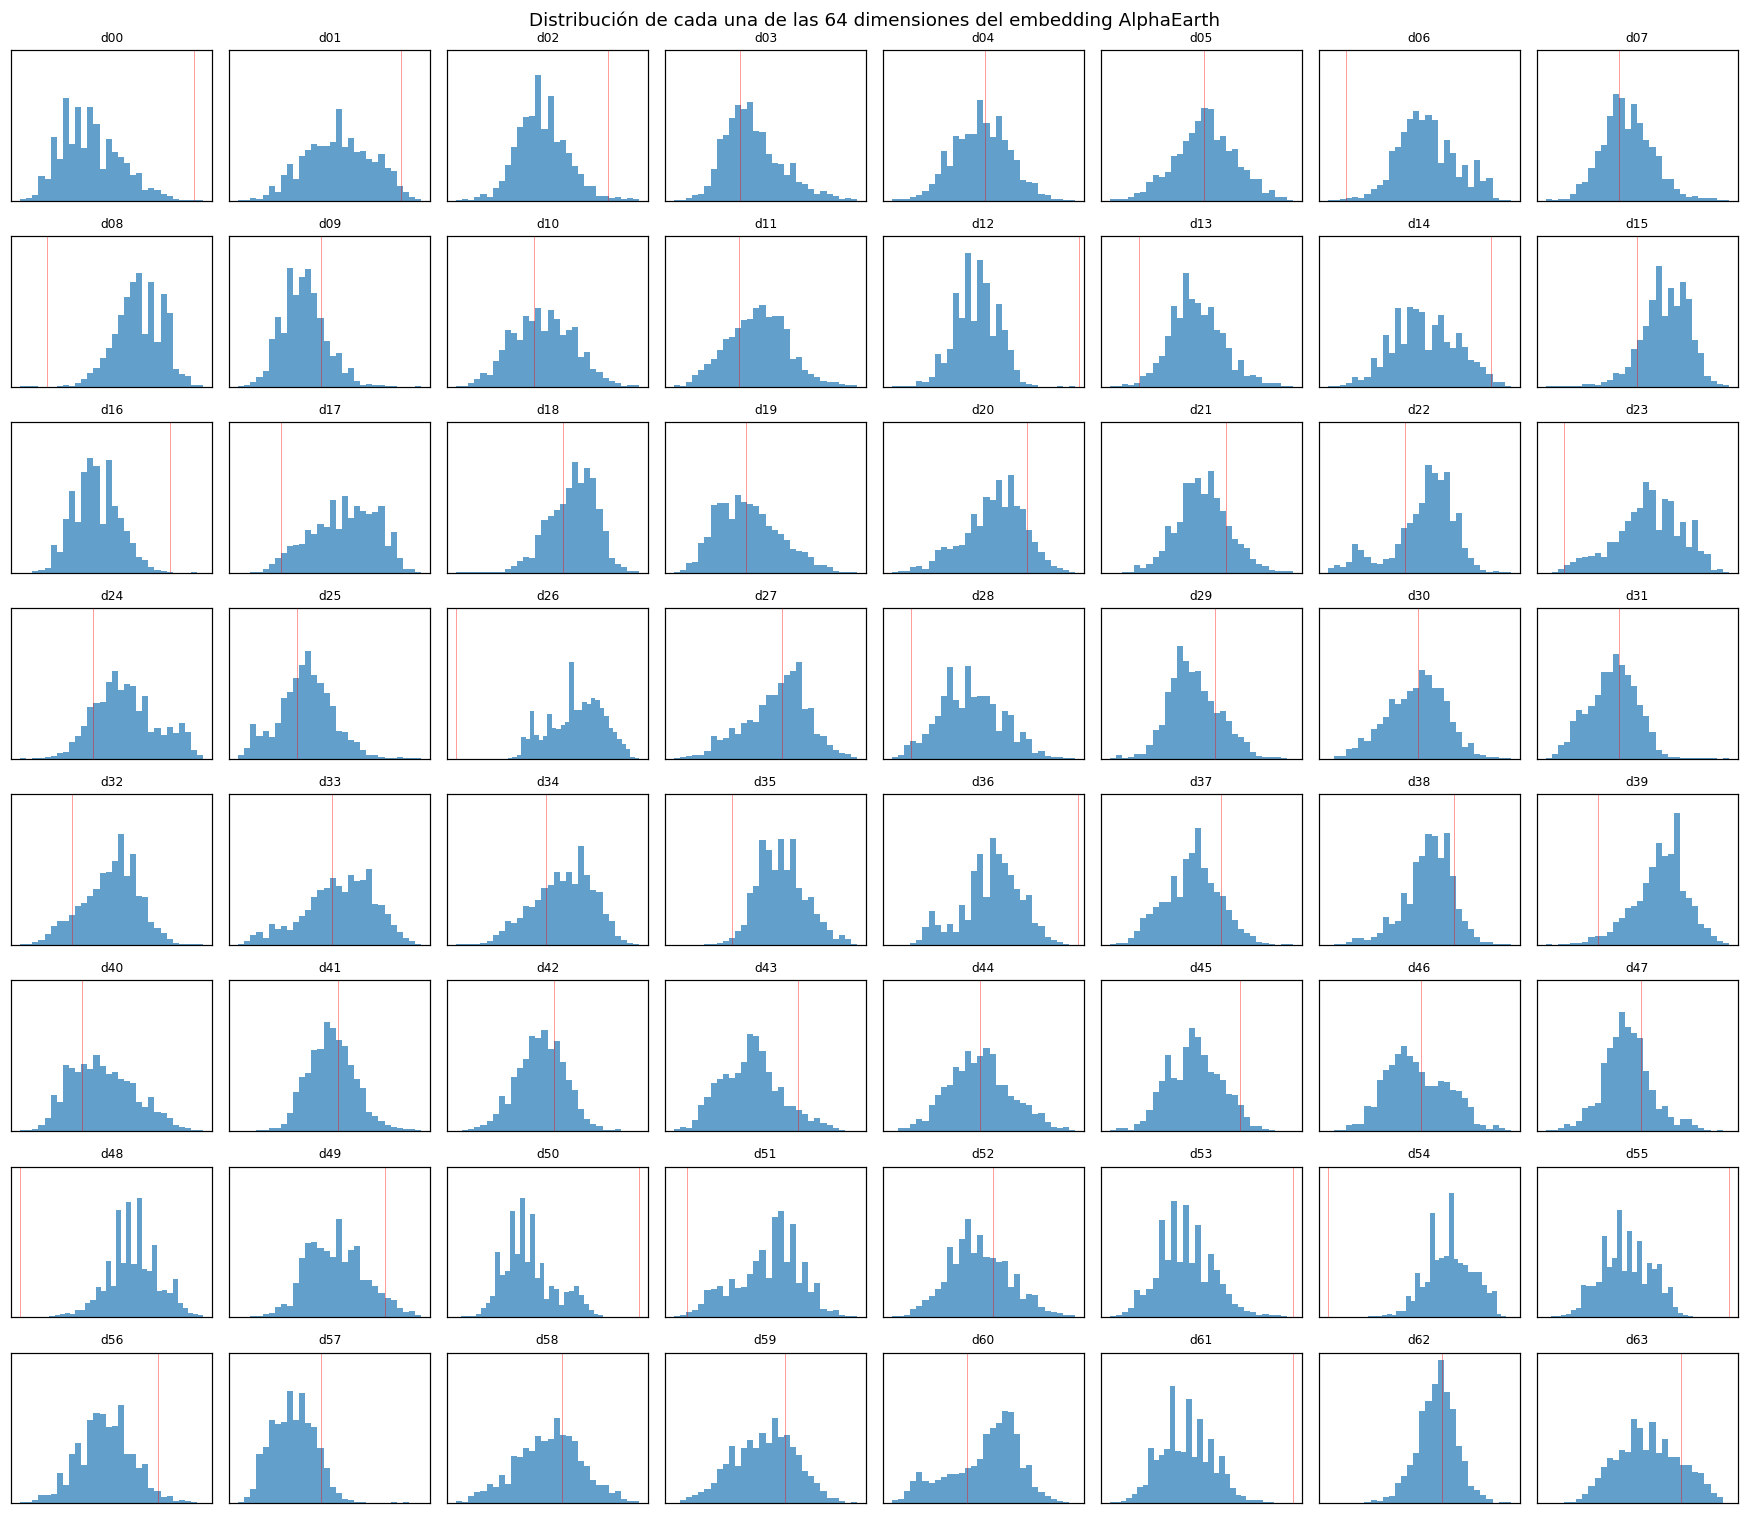

Cada histograma muestra una de las 64 dimensiones. La línea roja vertical marca el cero. Dimensiones centradas y aproximadamente simétricas son normales en un foundation model bien entrenado.

In [5]:
# (d) Distribucion por dimension: violin grid 8x8 para inspeccion visual completa.
fig, axes = plt.subplots(8, 8, figsize=(16, 14), sharey=True)
for d in range(n_dims):
    ax = axes[d // 8, d % 8]
    ax.hist(ae_matrix[:, d], bins=30, color='#1f77b4', alpha=0.7, edgecolor='none')
    ax.axvline(0, color='red', linewidth=0.5, alpha=0.5)
    ax.set_title(f'd{d:02d}', fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle('Distribución de cada una de las 64 dimensiones del embedding AlphaEarth', fontsize=12)
plt.tight_layout()
dim_dist_path = REPORTS_DIR / 'ae_dim_distributions.png'
fig.savefig(dim_dist_path, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(dim_dist_path)))
display(Markdown(
    'Cada histograma muestra una de las 64 dimensiones. La línea roja vertical marca el cero. '
    'Dimensiones centradas y aproximadamente simétricas son normales en un foundation model bien entrenado.'
))


**Correlación cruzada entre dimensiones del embedding**  
- Media `|r|` = `0.2405`, máx `|r|` = `0.7906`, mediana `|r|` = `0.2182`  
- Fracción con `|r| < 0.1` (casi ortogonales): `24.85%`  
- Fracción con `|r| > 0.5` (acopladas): `8.53%`

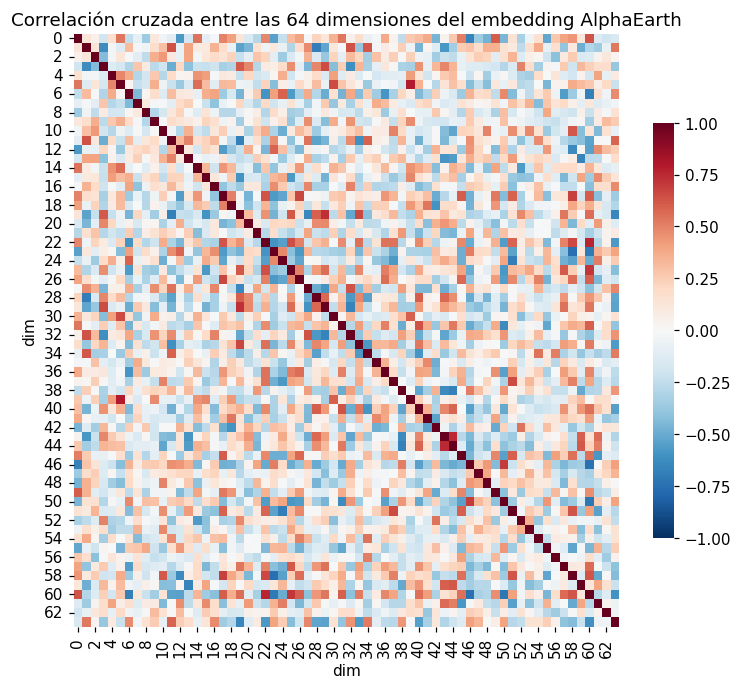

In [6]:
# Matriz de correlacion cruzada entre las 64 dimensiones.
corr_ae = np.corrcoef(ae_matrix, rowvar=False)
off_diag = corr_ae[~np.eye(corr_ae.shape[0], dtype=bool)]
frac_high_corr = float((np.abs(off_diag) > 0.5).mean())
frac_low_corr = float((np.abs(off_diag) < 0.1).mean())
display(Markdown(
    f'**Correlación cruzada entre dimensiones del embedding**  \n'
    f'- Media `|r|` = `{np.abs(off_diag).mean():.4f}`, máx `|r|` = `{np.abs(off_diag).max():.4f}`, '
    f'mediana `|r|` = `{np.median(np.abs(off_diag)):.4f}`  \n'
    f'- Fracción con `|r| < 0.1` (casi ortogonales): `{frac_low_corr:.2%}`  \n'
    f'- Fracción con `|r| > 0.5` (acopladas): `{frac_high_corr:.2%}`'
))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_ae, cmap='RdBu_r', vmin=-1.0, vmax=1.0, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlación cruzada entre las 64 dimensiones del embedding AlphaEarth')
ax.set_xlabel('dim')
ax.set_ylabel('dim')
fig_corr_path = REPORTS_DIR / 'ae_correlation_64x64.png'
fig.savefig(fig_corr_path, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(fig_corr_path)))


## 3. Estabilidad inter-anual del embedding (2022-2025 Italia)

Una pregunta crítica antes de usar AlphaEarth como feature productiva
es: ¿el embedding de una misma parcela cambia mucho entre años? Si
los embeddings son inestables el modelo downstream tendrá que
aprender ruido inter-anual; si son estables podemos confiar en
comparaciones temporales. Usamos cuatro snapshots cacheados sobre
las mismas coordenadas italianas (2022, 2023, 2024, 2025) y
medimos la similitud coseno año-a-año por píxel.


**Estabilidad inter-anual sobre `500` píxeles comunes a los `4` años**  
Cosine similarity entre vectores AE del mismo píxel en años consecutivos. Valores cercanos a 1.0 indican que el embedding es estable año-a-año; valores bajos delatan ruido temporal en el foundation model. Reporte → `reports\feature_fusion\ae_temporal_stability.csv`

year_a,year_b,n_pixels,cos_sim_mean,cos_sim_p05,cos_sim_p50,cos_sim_p95,cos_sim_min
i64,i64,i64,f64,f64,f64,f64,f64
2022,2023,500,0.951751,0.851499,0.966936,0.99756,0.546187
2023,2024,500,0.953147,0.834965,0.974526,0.996612,0.652696
2024,2025,500,0.953686,0.819968,0.97626,0.997117,0.539294


C:\Users\arthu\AppData\Local\Temp\ipykernel_23088\1780838875.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cos_per_pair, labels=pair_labels, showmeans=True, meanline=True)


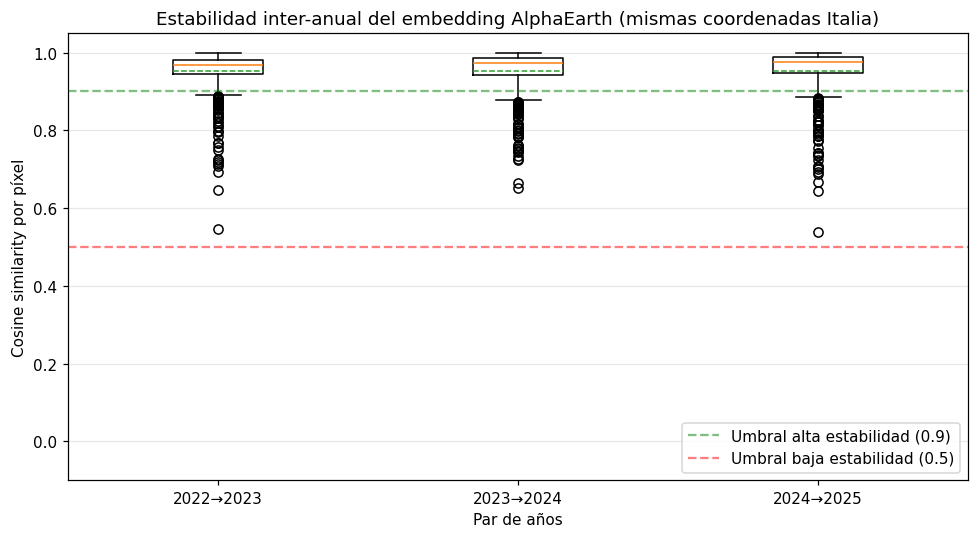

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

available_years = sorted(yr for yr, p in STAB_PARQUETS.items() if p.exists())

if len(available_years) >= 2:
    stab_frames = {yr: pl.read_parquet(STAB_PARQUETS[yr]) for yr in available_years}
    # Join progresivo por px_id, lon, lat para tener vectores comparables.
    common_ids = set(stab_frames[available_years[0]]['px_id'].to_list())
    for yr in available_years[1:]:
        common_ids &= set(stab_frames[yr]['px_id'].to_list())
    common_ids_list = sorted(common_ids)
    n_common = len(common_ids_list)

    # Construir matriz pixel x ano x 64.
    pivot = {}
    for yr in available_years:
        df_yr = stab_frames[yr].filter(pl.col('px_id').is_in(common_ids_list)).sort('px_id')
        mat = df_yr.select([f'dim_{i:02d}' for i in range(64)]).to_numpy().astype(np.float64)
        pivot[yr] = mat

    # Cosine similarity por pixel entre anos consecutivos.
    stab_rows = []
    for a, b in zip(available_years[:-1], available_years[1:]):
        mat_a, mat_b = pivot[a], pivot[b]
        # Cosine sim diagonal sin construir matriz NxN.
        dot = (mat_a * mat_b).sum(axis=1)
        norm_a = np.linalg.norm(mat_a, axis=1)
        norm_b = np.linalg.norm(mat_b, axis=1)
        cos = dot / np.maximum(norm_a * norm_b, 1e-12)
        stab_rows.append({
            'year_a': a,
            'year_b': b,
            'n_pixels': len(cos),
            'cos_sim_mean': float(cos.mean()),
            'cos_sim_p05': float(np.percentile(cos, 5)),
            'cos_sim_p50': float(np.percentile(cos, 50)),
            'cos_sim_p95': float(np.percentile(cos, 95)),
            'cos_sim_min': float(cos.min()),
        })

    stab_df = pl.DataFrame(stab_rows)
    stab_path = REPORTS_DIR / 'ae_temporal_stability.csv'
    stab_df.write_csv(stab_path)

    display(Markdown(
        f'**Estabilidad inter-anual sobre `{n_common}` píxeles comunes a los `{len(available_years)}` años**  \n'
        f'Cosine similarity entre vectores AE del mismo píxel en años consecutivos. '
        f'Valores cercanos a 1.0 indican que el embedding es estable año-a-año; '
        f'valores bajos delatan ruido temporal en el foundation model. '
        f'Reporte → `{stab_path.relative_to(REPO_ROOT)}`'
    ))
    display(stab_df)

    # Boxplot de cosine similarity por par de anos.
    cos_per_pair = []
    pair_labels = []
    for a, b in zip(available_years[:-1], available_years[1:]):
        mat_a, mat_b = pivot[a], pivot[b]
        dot = (mat_a * mat_b).sum(axis=1)
        norm_a = np.linalg.norm(mat_a, axis=1)
        norm_b = np.linalg.norm(mat_b, axis=1)
        cos_per_pair.append(dot / np.maximum(norm_a * norm_b, 1e-12))
        pair_labels.append(f'{a}→{b}')

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(cos_per_pair, labels=pair_labels, showmeans=True, meanline=True)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='Umbral alta estabilidad (0.9)')
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Umbral baja estabilidad (0.5)')
    ax.set_ylabel('Cosine similarity por píxel')
    ax.set_xlabel('Par de años')
    ax.set_title('Estabilidad inter-anual del embedding AlphaEarth (mismas coordenadas Italia)')
    ax.set_ylim(-0.1, 1.05)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    stab_png = REPORTS_DIR / 'ae_temporal_stability.png'
    fig.savefig(stab_png, dpi=110, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(stab_png)))
    stability_computed = True
else:
    display(Markdown(
        f'**Análisis de estabilidad omitido**: solo `{len(available_years)}` año(s) cacheado(s) '
        f'en `data/cache/gee/alphaearth_at_italia_stab_*.parquet`. Se requieren al menos 2.'
    ))
    stab_df = pl.DataFrame()
    stability_computed = False


## 4. Comparativa indicativa: AE 64-dim vs spectral-temporal 187-dim

Pregunta agronómica directa: ¿vale más el embedding pre-entrenado de
64 dimensiones que las 187 features espectro-temporales hechas a mano
(NDVI, EVI, GCVI, FFT, fenología) del notebook anterior?

**Caveat metodológico**: los dos lados se evalúan sobre subsets
distintos del mismo dataset (PASTIS-FR). El bloque AE consume las
10 parcelas de los patches cacheados a nivel píxel; el bloque
spectral-temporal consume las 77 parcelas del subset estratificado
agregado a nivel parcela. La comparación es **indicativa, no
estrictamente controlada**, pero ofrece una primera lectura del
valor diferencial.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def cv_f1_macro(X: np.ndarray, y: np.ndarray, n_splits: int = 3, seed: int = 42) -> tuple[float, float]:
    """Compute mean+std F1-macro under StratifiedKFold with safe degeneration."""
    # Adjust n_splits to min class count.
    unique, counts = np.unique(y, return_counts=True)
    safe_splits = max(2, min(n_splits, int(counts.min())))
    if len(unique) < 2 or X.shape[0] < safe_splits * 2:
        return float('nan'), float('nan')
    skf = StratifiedKFold(n_splits=safe_splits, shuffle=True, random_state=seed)
    scores = []
    for train_idx, test_idx in skf.split(X, y):
        clf = RandomForestClassifier(n_estimators=80, random_state=seed, n_jobs=-1)
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        scores.append(f1_score(y[test_idx], pred, average='macro', zero_division=0))
    return float(np.mean(scores)), float(np.std(scores))

# Lado AlphaEarth: 64 dims pixel-level con label PASTIS.
X_ae_px = ae_matrix
y_ae_px = df_pixels.get_column('class_id').to_numpy()
ae_f1_mean, ae_f1_std = cv_f1_macro(X_ae_px, y_ae_px, n_splits=3)

# Lado spectral-temporal: lee subset del notebook anterior si existe.
comparison_rows = [
    {
        'fuente': 'AlphaEarth 64-dim (pixel-level, n=' + str(len(y_ae_px)) + ')',
        'n_features': X_ae_px.shape[1],
        'n_samples': X_ae_px.shape[0],
        'n_classes': int(np.unique(y_ae_px).size),
        'f1_macro_mean': round(ae_f1_mean, 4),
        'f1_macro_std': round(ae_f1_std, 4),
    },
]

if ST_SUBSET.exists():
    st_df = pl.read_parquet(ST_SUBSET)
    st_feat_cols = [c for c in st_df.columns if c not in ('parcel_id', 'year', 'fold', 'class_id')]
    X_st = st_df.select(st_feat_cols).to_numpy().astype(np.float64)
    X_st = np.nan_to_num(X_st, nan=0.0)
    y_st = st_df.get_column('class_id').to_numpy()
    st_f1_mean, st_f1_std = cv_f1_macro(X_st, y_st, n_splits=3)
    comparison_rows.append({
        'fuente': 'Spectral-temporal manual (parcel-level, n=' + str(len(y_st)) + ')',
        'n_features': X_st.shape[1],
        'n_samples': X_st.shape[0],
        'n_classes': int(np.unique(y_st).size),
        'f1_macro_mean': round(st_f1_mean, 4),
        'f1_macro_std': round(st_f1_std, 4),
    })

comp_df = pl.DataFrame(comparison_rows)
comp_path = REPORTS_DIR / 'ae_vs_spectral_temporal_indicative.csv'
comp_df.write_csv(comp_path)
display(Markdown(
    f'**Comparativa indicativa AE vs spectral-temporal** → `{comp_path.relative_to(REPO_ROOT)}`  \n'
    f'Random Forest con 80 árboles bajo `StratifiedKFold` (3 splits, adaptado a clase minoritaria). '
    f'Sirve para situar el valor relativo, no como benchmark final.'
))
display(comp_df)


**Comparativa indicativa AE vs spectral-temporal** → `reports\feature_fusion\ae_vs_spectral_temporal_indicative.csv`  
Random Forest con 80 árboles bajo `StratifiedKFold` (3 splits, adaptado a clase minoritaria). Sirve para situar el valor relativo, no como benchmark final.

fuente,n_features,n_samples,n_classes,f1_macro_mean,f1_macro_std
str,i64,i64,i64,f64,f64
"""AlphaEarth 64-dim (pixel-level, n=6000)""",64,6000,13,0.7398,0.0363
"""Spectral-temporal manual (parcel-level, n=77)""",185,77,17,0.1682,0.0088


## 5. Composición canónica de la matriz de fusión (189 columnas)

El módulo `ml.features.fusion` define el contrato de columnas
esperadas cuando todas las fuentes externas están disponibles. Lo
exponemos como tabla legible para entender qué aporta cada bloque
antes de operar sobre el subconjunto que tenemos cacheado.


In [9]:
# Descomposicion del banco de columnas esperado por el contrato fusion.
blocks = [
    ('alphaearth', 64, 'media del embedding 64-dim por parcela'),
    ('indices_stats', 85, f'{len(INDEX_NAMES)} indices x {len(FUSION_STATS)} stats temporales = {len(INDEX_NAMES) * len(FUSION_STATS)}'),
    ('sentinel1', 10, 'backscatter VV+VH x 5 stats con preset GRD IW asc+desc despeckle Lee 7x7'),
    ('srtm', 3, 'elevacion media + slope medio + aspect dominante (string cardinal)'),
    ('era5_monthly', 24, 'temperatura media + precipitacion acumulada por mes (12 + 12)'),
    ('geometry', 3, 'area en ha + perimetro en m + razon de elongacion Polsby-Popper'),
    ('farslip', 512, 'embedding CLIP destilado parche-a-parche (opcional)'),
]
blocks_df = pl.DataFrame({
    'block': [b[0] for b in blocks],
    'n_cols': [b[1] for b in blocks],
    'description': [b[2] for b in blocks],
})
total_no_farslip = sum(b[1] for b in blocks if b[0] != 'farslip')
total_with_farslip = sum(b[1] for b in blocks)
display(Markdown(
    f'**Bloques contratados por el módulo de fusión**: `{BLOCK_NAMES}`  \n'
    f'**Total esperado sin bloque opcional**: `{total_no_farslip}` columnas '
    f'(constante exportada `EXPECTED_COL_COUNT_NO_FARSLIP = {EXPECTED_COL_COUNT_NO_FARSLIP}`)  \n'
    f'**Total esperado con bloque opcional**: `{total_with_farslip}` columnas '
    f'(constante exportada `EXPECTED_COL_COUNT_WITH_FARSLIP = {EXPECTED_COL_COUNT_WITH_FARSLIP}`)'
))
display(blocks_df)
blocks_df.write_csv(REPORTS_DIR / 'fusion_block_contract.csv')


**Bloques contratados por el módulo de fusión**: `('alphaearth', 'indices_stats', 'sentinel1', 'srtm', 'era5_monthly', 'geometry', 'farslip')`  
**Total esperado sin bloque opcional**: `189` columnas (constante exportada `EXPECTED_COL_COUNT_NO_FARSLIP = 189`)  
**Total esperado con bloque opcional**: `701` columnas (constante exportada `EXPECTED_COL_COUNT_WITH_FARSLIP = 701`)

block,n_cols,description
str,i64,str
"""alphaearth""",64,"""media del embedding 64-dim por parcela"""
"""indices_stats""",85,"""17 indices x 5 stats temporales = 85"""
"""sentinel1""",10,"""backscatter VV+VH x 5 stats con preset GRD IW asc+desc despe…"
"""srtm""",3,"""elevacion media + slope medio + aspect dominante (string car…"
"""era5_monthly""",24,"""temperatura media + precipitacion acumulada por mes (12 + 12…"
"""geometry""",3,"""area en ha + perimetro en m + razon de elongacion Polsby-Pop…"
"""farslip""",512,"""embedding CLIP destilado parche-a-parche (opcional)"""


## 6. Agregación a nivel parcela y UMAP por clase y grupo agronómico

Los 6000 puntos AlphaEarth viven a nivel píxel. La unidad de
decisión agronómica es la parcela: agregamos por `patch_id`
(que actúa como `parcel_id` proxy en este dataset) tomando la
media de cada dimensión y la clase modal como etiqueta dominante.
Después comparamos dos vistas UMAP: una coloreada por las 17
clases PASTIS raw, otra por los 5 grupos agronómicos
(`cereals`, `oilseeds_legumes`, `permanent_long_cycle`,
`root_crops`, `special_crops`). Si AlphaEarth captura jerarquía
botánica, la vista por grupo debería mostrar clusters más
limpios.


In [10]:
ae_dim_cols = [c for c in df_pixels.columns if c.startswith('dim_')]

parcel_frame = (
    df_pixels.group_by('patch_id')
    .agg([
        *[pl.col(c).mean().alias(c.replace('dim_', 'ae_')) for c in ae_dim_cols],
        pl.col('lon').mean().alias('lon'),
        pl.col('lat').mean().alias('lat'),
        pl.col('class_id').mode().first().alias('class_id'),
        pl.col('agronomic_group').mode().first().alias('agronomic_group'),
        pl.len().alias('n_pixels'),
    ])
    .with_columns(pl.col('patch_id').cast(pl.Int64).alias('parcel_id'))
    .drop('patch_id')
    .with_columns(pl.lit(2019).alias('year'))
    .sort('parcel_id')
)

display(Markdown(
    f'**Frame agregado a nivel parcela**: `{parcel_frame.shape[0]}` parcelas x '
    f'`{parcel_frame.shape[1]}` columnas  \n'
    f'**Píxeles por parcela**: media `{parcel_frame["n_pixels"].mean():.0f}`, '
    f'mín `{parcel_frame["n_pixels"].min()}`, máx `{parcel_frame["n_pixels"].max()}`'
))
display(parcel_frame.select(['parcel_id', 'class_id', 'agronomic_group', 'n_pixels', 'lon', 'lat', 'ae_00', 'ae_01']).head(10))


**Frame agregado a nivel parcela**: `10` parcelas x `71` columnas  
**Píxeles por parcela**: media `600`, mín `600`, máx `600`

parcel_id,class_id,agronomic_group,n_pixels,lon,lat,ae_00,ae_01
i64,i16,str,u32,f64,f64,f64,f64
10000,12,"""special_crops""",600,-1.262477,49.629333,-0.186568,-0.114084
10001,1,"""permanent_long_cycle""",600,-1.532617,48.930383,-0.210191,-0.195789
10002,12,"""special_crops""",600,-1.297329,49.630448,-0.18003,-0.092907
10003,2,"""cereals""",600,-0.356597,49.300929,-0.250606,-0.126589
10004,12,"""special_crops""",600,-1.591269,49.194862,-0.155466,-0.154949
10005,12,"""special_crops""",600,-1.580283,49.024274,-0.193948,-0.160125
10006,1,"""permanent_long_cycle""",600,-1.557129,49.219372,-0.213204,-0.128437
10007,12,"""special_crops""",600,-1.232694,49.617456,-0.142851,-0.089479
10008,12,"""special_crops""",600,-1.591191,49.176467,-0.189287,-0.198547


2026-05-17 23:08:41 [info     ] umap_2d_fitted                 n_features=64 n_neighbors=15 n_samples=2000 random_state=42


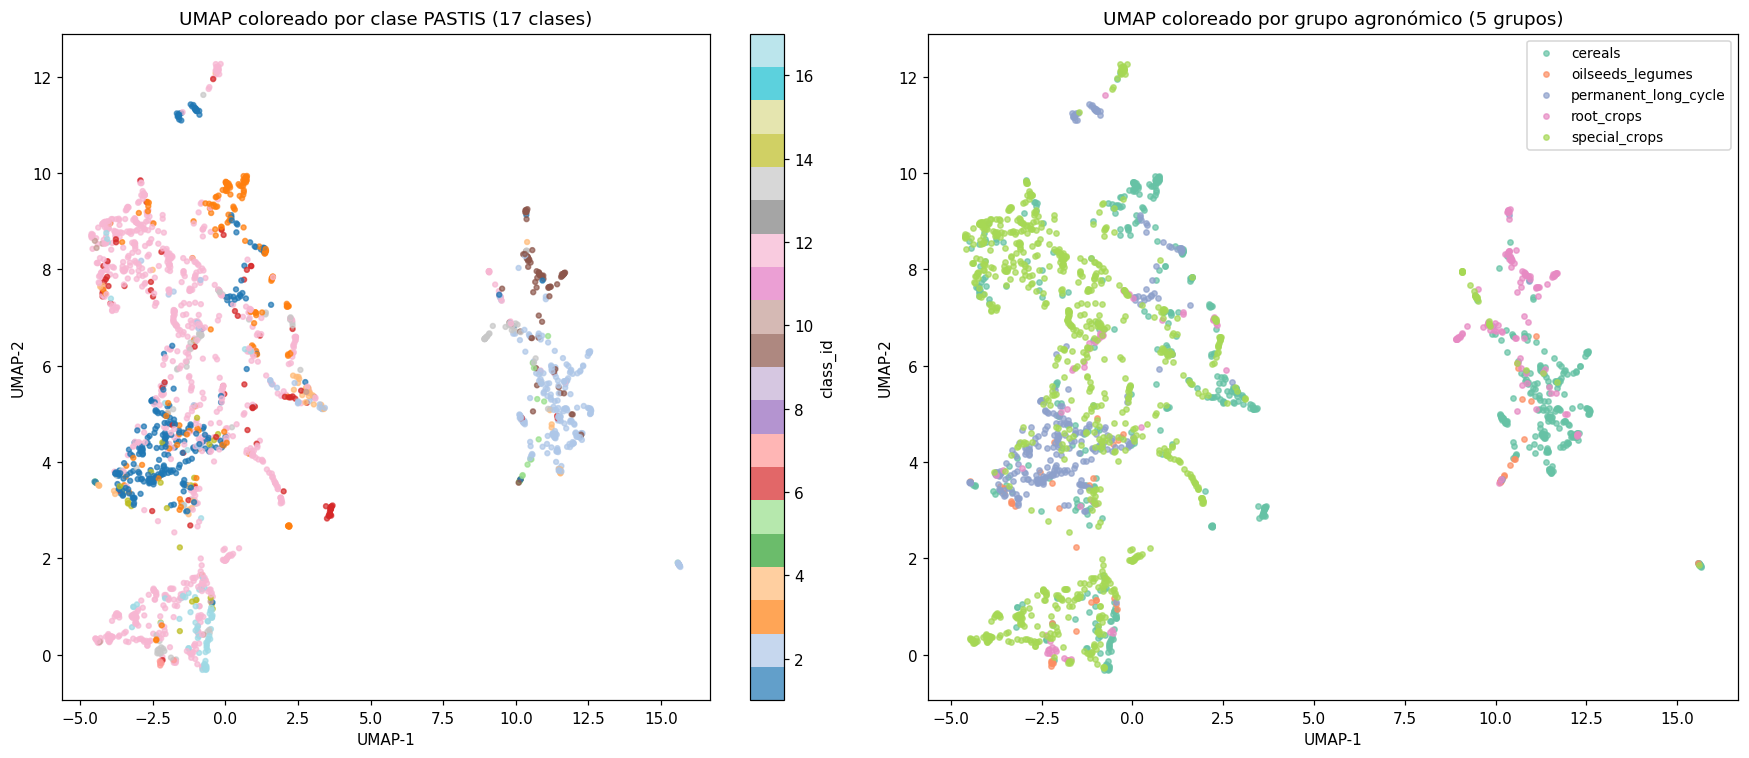

A la izquierda los 17 colores de clase PASTIS raw. A la derecha los 5 grupos agronómicos. Si AlphaEarth captura jerarquía botánica, los grupos deberían formar regiones más coherentes.

In [11]:
# UMAP 2D del banco pixel-level con DOS coloraciones: class_id y agronomic_group.
sample_n = min(ae_matrix.shape[0], 2000)
rng = np.random.default_rng(42)
sample_idx = rng.choice(ae_matrix.shape[0], size=sample_n, replace=False)
y_class = df_pixels.get_column('class_id').to_numpy()
y_group = df_pixels.get_column('agronomic_group').to_numpy()
umap_emb = fit_umap_2d(ae_matrix[sample_idx], y=y_class[sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Vista A: por class_id (17 clases, tab20).
scatter_a = axes[0].scatter(
    umap_emb[:, 0], umap_emb[:, 1],
    c=y_class[sample_idx], cmap='tab20', s=10, alpha=0.7,
)
axes[0].set_title('UMAP coloreado por clase PASTIS (17 clases)')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')
plt.colorbar(scatter_a, ax=axes[0], label='class_id')

# Vista B: por agronomic_group (5 grupos, categorica).
groups_sample = y_group[sample_idx]
unique_groups = sorted(set(groups_sample))
group_palette = sns.color_palette('Set2', len(unique_groups))
for i, g in enumerate(unique_groups):
    mask = groups_sample == g
    axes[1].scatter(
        umap_emb[mask, 0], umap_emb[mask, 1],
        color=group_palette[i], label=g, s=12, alpha=0.7,
    )
axes[1].set_title('UMAP coloreado por grupo agronómico (5 grupos)')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
umap_dual_path = REPORTS_DIR / 'ae_umap_class_and_group.png'
fig.savefig(umap_dual_path, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(umap_dual_path)))
display(Markdown(
    'A la izquierda los 17 colores de clase PASTIS raw. A la derecha los 5 grupos agronómicos. '
    'Si AlphaEarth captura jerarquía botánica, los grupos deberían formar regiones más coherentes.'
))


## 7. Spatial K-fold con H3 + KMeans + buffer

El split aleatorio sobre datos georreferenciados es la receta más
común para inflar métricas falsamente: parcelas vecinas comparten
clima, suelo y manejo agronómico, por lo que un fold aleatorio
permite que el modelo memorice contexto regional en lugar de
aprender la firma del cultivo. La alternativa correcta es
particionar el espacio en bloques disjuntos. Usamos H3 a resolución
5 (celdas hexagonales de ~252 km²), agrupamos celdas con KMeans
para balancear el tamaño de fold y aplicamos un buffer de exclusión
para parcelas cercanas a las fronteras inter-fold.

Con solo 10 parcelas en este dataset la división en 5 folds es
degenerada (cada fold queda con muy pocos elementos), por lo que
usamos `k=3` para demostración. La API es la misma que se usaría
sobre las decenas de miles de parcelas del set completo.


In [12]:
import geopandas as gpd
from shapely.geometry import Point

gdf_parcels = gpd.GeoDataFrame(
    parcel_frame.select(['parcel_id', 'lon', 'lat']).to_pandas(),
    geometry=[Point(lon, lat) for lon, lat in zip(parcel_frame['lon'].to_list(), parcel_frame['lat'].to_list())],
    crs='EPSG:4326',
)

k_folds = 3 if len(gdf_parcels) < 25 else 5
fold_assignments = build_spatial_kfold(
    gdf_parcels, k=k_folds, h3_res=5, buffer_km=1.0, val_fraction=0.2, random_state=42
)

# Map parcel_id -> class_id para reportar balance de clases por fold.
pid_to_class = dict(zip(
    parcel_frame.get_column('parcel_id').to_list(),
    parcel_frame.get_column('class_id').to_list(),
))

fold_rows = []
for fid, fa in enumerate(fold_assignments):
    test_classes = [pid_to_class.get(int(pid), -1) for pid in fa.test_ids]
    fold_rows.append({
        'fold_id': fid,
        'n_train': len(fa.train_ids),
        'n_val': len(fa.val_ids),
        'n_test': len(fa.test_ids),
        'test_classes': str(sorted(set(test_classes))) if test_classes else '[]',
        'train_ids_sample': str(list(fa.train_ids)[:5]),
    })
fold_df = pl.DataFrame(fold_rows)
fold_path = REPORTS_DIR / 'spatial_folds_summary.csv'
fold_df.write_csv(fold_path)
display(Markdown(
    f'**Spatial K-fold (k={k_folds}, H3 res 5, buffer 1 km)** → `{fold_path.relative_to(REPO_ROOT)}`  \n'
    f'La columna `test_classes` muestra qué clases caen en el split test de cada fold; '
    f'con 10 parcelas la cobertura inevitablemente es parcial.'
))
display(fold_df)


2026-05-17 23:08:44 [info     ] spatial_kfold_built            buffer_km=1.0 effective_k=3 excluded=0 h3_res=5 k=3 n_parcels=10 n_unique_h3=6


**Spatial K-fold (k=3, H3 res 5, buffer 1 km)** → `reports\feature_fusion\spatial_folds_summary.csv`  
La columna `test_classes` muestra qué clases caen en el split test de cada fold; con 10 parcelas la cobertura inevitablemente es parcial.

fold_id,n_train,n_val,n_test,test_classes,train_ids_sample
i64,i64,i64,i64,str,str
0,6,1,3,"""[12]""","""[10004, 10009, 10006, 10003, 10008]"""
1,4,1,5,"""[1, 12]""","""[10009, 10000, 10002, 10007]"""
2,6,2,2,"""[2]""","""[10005, 10002, 10006, 10004, 10000]"""


In [13]:
# Verificacion de zero leakage: ningun parcel_id en dos folds simultaneamente.
all_test_ids = []
for fa in fold_assignments:
    all_test_ids.extend(fa.test_ids)
duplicates = len(all_test_ids) - len(set(all_test_ids))
display(Markdown(
    f'**Parcelas en test acumulado**: `{len(all_test_ids)}` totales / `{len(set(all_test_ids))}` únicas  \n'
    f'**Duplicados entre folds**: `{duplicates}` (esperado 0 → sin fuga cross-fold)'
))


**Parcelas en test acumulado**: `10` totales / `10` únicas  
**Duplicados entre folds**: `0` (esperado 0 → sin fuga cross-fold)

## 8. Scaler entrenado solo sobre train

El `StandardScaler` se ajusta exclusivamente con los `parcel_id` del
split train del Fold-0. La función `fit_scaler_on_train` valida
explícitamente que `train_ids` no interseque con `val_ids` ni
`test_ids` y persiste el scaler con joblib (formato firmado,
compatible con DVC). El artefacto resultante puede cargarse desde
almacenamiento remoto y aplicar `.transform()` sobre nuevos lotes
sin filtración de información del val o test.


In [14]:
ae_cols_final = [c for c in parcel_frame.columns if c.startswith('ae_')]
fa0 = fold_assignments[0]

scaler_path = REPORTS_DIR / 'parcel_features_scaler_v1.pkl'
scaler = fit_scaler_on_train(
    parcel_frame,
    train_ids=tuple(fa0.train_ids),
    feature_cols=tuple(ae_cols_final),
    scaler_path=scaler_path,
    version='v1_fusion_notebook',
    val_ids=tuple(fa0.val_ids),
    test_ids=tuple(fa0.test_ids),
)

meta = scaler._agrosat_meta  # type: ignore[attr-defined]
display(Markdown(
    f'**Scaler persistido en**: `{scaler_path.relative_to(REPO_ROOT)}`  \n'
    f'**Versión**: `{meta["version"]}` | **n_train**: `{meta["n_train"]}` | '
    f'**features ajustadas**: `{len(meta["feature_cols"])}`  \n'
    f'**Tamaño joblib**: `{scaler_path.stat().st_size / 1024:.1f} KB`'
))


2026-05-17 23:08:44 [info     ] scaler_persisted               n_features=64 n_train=6 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\reports\feature_fusion\parcel_features_scaler_v1.pkl version=v1_fusion_notebook


**Scaler persistido en**: `reports\feature_fusion\parcel_features_scaler_v1.pkl`  
**Versión**: `v1_fusion_notebook` | **n_train**: `6` | **features ajustadas**: `64`  
**Tamaño joblib**: `2.6 KB`

In [15]:
# Aplicacion del scaler sobre los splits train, val y test del Fold-0.
def slice_matrix(parcels_frame: pl.DataFrame, ids: tuple[int, ...], feature_cols: list[str]) -> np.ndarray:
    if not ids:
        return np.zeros((0, len(feature_cols)), dtype=np.float64)
    int_ids = [int(i) for i in ids]
    sub = parcels_frame.filter(pl.col('parcel_id').is_in(int_ids))
    return sub.select(feature_cols).to_numpy().astype(np.float64)

X_train = slice_matrix(parcel_frame, tuple(fa0.train_ids), ae_cols_final)
X_val = slice_matrix(parcel_frame, tuple(fa0.val_ids), ae_cols_final)
X_test = slice_matrix(parcel_frame, tuple(fa0.test_ids), ae_cols_final)

rows = []
for split_name, mat in (('train', X_train), ('val', X_val), ('test', X_test)):
    if mat.shape[0] == 0:
        rows.append({'split': split_name, 'n': 0, 'mean_post': float('nan'), 'std_post': float('nan')})
        continue
    scaled = scaler.transform(mat)
    rows.append({
        'split': split_name,
        'n': mat.shape[0],
        'mean_post': float(scaled.mean()),
        'std_post': float(scaled.std()),
    })
display(Markdown('**Estadísticas post-scaler por split** (train debería tener mean=0, std=1):'))
display(pl.DataFrame(rows))


**Estadísticas post-scaler por split** (train debería tener mean=0, std=1):

split,n,mean_post,std_post
str,i64,f64,f64
"""train""",6,-1.7347e-17,1.0
"""val""",1,0.151572,1.313191
"""test""",3,0.059215,1.492286


## 9. Selección y normalización sobre el bloque AlphaEarth

Aplicamos la suite de selección sobre el bloque AlphaEarth para
demostrar que la API es la misma que el notebook anterior:
filtro de varianza, deduplicación por correlación, ANOVA F
supervisado, proyección PCA y `ColumnTransformer` reutilizable.


In [16]:
# Frame con parcel_id + year + 64 dimensiones AE para la suite de seleccion.
X_ae = parcel_frame.select(['parcel_id', 'year', *ae_cols_final])
y_ae = parcel_frame.get_column('class_id')

X_var, var_report = apply_variance_threshold(X_ae, threshold=0.0001)
X_corr, corr_report = drop_correlated_features(X_var, threshold=0.9, method='pearson')
display(Markdown(
    f'**Filtro de varianza (0.0001)**: removidas `{len(var_report["removed"])}`  \n'
    f'**Pearson |r|>0.9**: removidas `{len(corr_report["removed"])}`  \n'
    f'**Forma final**: `{X_corr.shape[0]} x {X_corr.shape[1] - 2}` características (sin parcel_id/year)'
))


2026-05-17 23:08:45 [info     ] variance_threshold_applied     n_kept=63 n_removed=1 threshold=0.0001
2026-05-17 23:08:45 [info     ] correlated_features_dropped    method=pearson n_kept=46 n_removed=17 threshold=0.9


**Filtro de varianza (0.0001)**: removidas `1`  
**Pearson |r|>0.9**: removidas `17`  
**Forma final**: `10 x 46` características (sin parcel_id/year)

In [17]:
# ANOVA F sobre el bloque AlphaEarth (cuando hay suficientes clases).
if y_ae.n_unique() >= 2:
    _, anova_scores = anova_f_select(X_corr, y_ae, k_best=min(10, X_corr.shape[1] - 2))
    anova_df = pl.DataFrame({
        'feature': list(anova_scores.keys()),
        'f_value': list(anova_scores.values()),
    }).sort('f_value', descending=True)
    anova_path = REPORTS_DIR / 'ae_anova_f_top.csv'
    anova_df.write_csv(anova_path)
    display(Markdown(
        f'**Top dimensiones AlphaEarth por ANOVA F** (`{y_ae.n_unique()}` clases) → '
        f'`{anova_path.relative_to(REPO_ROOT)}`'
    ))
    display(anova_df.head(10))
else:
    display(Markdown('**ANOVA F omitido**: se requiere al menos 2 clases.'))
    anova_df = pl.DataFrame()


2026-05-17 23:08:45 [info     ] anova_f_select_done            k_best=10 n_features_in=46 n_features_out=10


**Top dimensiones AlphaEarth por ANOVA F** (`3` clases) → `reports\feature_fusion\ae_anova_f_top.csv`

feature,f_value
str,f64
"""ae_22""",44.447394
"""ae_29""",18.648694
"""ae_24""",15.963117
"""ae_31""",15.864503
"""ae_06""",13.282659
"""ae_47""",11.764735
"""ae_00""",10.659124
"""ae_32""",9.16134
"""ae_36""",7.0875


In [18]:
# Proyeccion PCA sobre el bloque AlphaEarth + ColumnTransformer reusable.
from sklearn.preprocessing import StandardScaler as SkScaler

feat_only = X_corr.drop(['parcel_id', 'year']).to_numpy().astype(np.float64)
feat_only = np.nan_to_num(feat_only, nan=0.0)
feat_std = SkScaler().fit_transform(feat_only)
pca_res = fit_pca(feat_std, target_variance=0.95)
display(Markdown(
    f'**PCA sobre bloque AlphaEarth**: `{pca_res["n_components"]}` componentes '
    f'capturan el 95% de la varianza (entrada: `{feat_std.shape[1]}` dimensiones).'
))

pre_linear = make_preprocessor(X_corr, strategy='linear')
pre_nn = make_preprocessor(X_corr, strategy='nn')
display(Markdown('**ColumnTransformer reutilizable construido para dos familias de modelo**'))
print(f'linear -> {pre_linear}')
print(f'nn     -> {pre_nn}')


2026-05-17 23:08:46 [info     ] pca_fitted                     cumulative_variance=0.9787514012103024 n_components=7 target_variance=0.95


**PCA sobre bloque AlphaEarth**: `7` componentes capturan el 95% de la varianza (entrada: `46` dimensiones).

2026-05-17 23:08:46 [info     ] preprocessor_built             categorical_encoder=None n_categorical=0 n_features=46 n_log1p=0 n_minmax=0 n_standard=38 n_yeo=8 strategy=linear
2026-05-17 23:08:46 [info     ] preprocessor_built             categorical_encoder=None n_categorical=0 n_features=46 n_log1p=0 n_minmax=38 n_standard=0 n_yeo=8 strategy=nn


**ColumnTransformer reutilizable construido para dos familias de modelo**

linear -> ColumnTransformer(transformers=[('standard', StandardScaler(),
                                 [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                  15, 16, 18, 19, 22, 23, 25, 26, 27, 28, 29,
                                  30, 31, 32, 33, 35, ...]),
                                ('yeo_johnson', PowerTransformer(),
                                 [2, 17, 20, 21, 24, 34, 38, 45])])
nn     -> ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                  15, 16, 18, 19, 22, 23, 25, 26, 27, 28, 29,
                                  30, 31, 32, 33, 35, ...]),
                                ('yeo_johnson', PowerTransformer(),
                                 [2, 17, 20, 21, 24, 34, 38, 45])])


## 10. Persistencia de outputs consumibles

Guardamos los dos niveles de granularidad (pixel-level y
parcel-level) más un manifiesto JSON que describe el contrato de
datos para que cualquier script downstream pueda cargar los
outputs sin reproducir el pipeline completo.


In [19]:
# Pixel-level: 64 dims AE + class_id + agronomic_group + coords.
pixel_export = df_pixels.select(['px_id', 'patch_id', 'lon', 'lat', 'class_id', 'class_name', 'agronomic_group', *ae_dim_cols])
pixel_path = REPORTS_DIR / 'ae_pixel_level.parquet'
pixel_export.write_parquet(pixel_path)

# Parcel-level: agregado + scaler.
parcel_path = REPORTS_DIR / 'ae_parcel_level.parquet'
parcel_frame.write_parquet(parcel_path)

manifest = {
    'pixel_level': {
        'path': str(pixel_path.relative_to(REPO_ROOT)),
        'n_pixels': pixel_export.height,
        'n_features': len(ae_dim_cols),
        'feature_prefix': 'dim_',
        'label_cols': ['class_id', 'class_name', 'agronomic_group'],
        'coord_cols': ['lon', 'lat'],
    },
    'parcel_level': {
        'path': str(parcel_path.relative_to(REPO_ROOT)),
        'n_parcels': parcel_frame.height,
        'n_features': len(ae_cols_final),
        'feature_prefix': 'ae_',
        'label_cols': ['class_id', 'agronomic_group'],
        'aggregation': 'mean per parcel; class_id and agronomic_group via mode',
    },
    'scaler': {
        'path': str(scaler_path.relative_to(REPO_ROOT)),
        'version': meta['version'],
        'fitted_on': f'train split of fold 0 ({meta["n_train"]} parcels)',
        'feature_cols': meta['feature_cols'],
    },
    'spatial_folds': {
        'k': k_folds,
        'h3_resolution': 5,
        'buffer_km': 1.0,
        'val_fraction': 0.2,
        'random_state': 42,
    },
    'pipeline_steps': [
        'apply_variance_threshold(threshold=0.0001)',
        'drop_correlated_features(threshold=0.9, method=pearson)',
    ],
    'pca_n_components_95pct': int(pca_res['n_components']),
}
manifest_path = REPORTS_DIR / 'fusion_manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

display(Markdown(
    f'**Pixel-level**: `{pixel_path.relative_to(REPO_ROOT)}` '
    f'(`{pixel_path.stat().st_size / 1024:.1f}` KB, `{pixel_export.height}` filas)  \n'
    f'**Parcel-level**: `{parcel_path.relative_to(REPO_ROOT)}` '
    f'(`{parcel_path.stat().st_size / 1024:.1f}` KB, `{parcel_frame.height}` filas)  \n'
    f'**Manifiesto**: `{manifest_path.relative_to(REPO_ROOT)}`'
))


**Pixel-level**: `reports\feature_fusion\ae_pixel_level.parquet` (`594.8` KB, `6000` filas)  
**Parcel-level**: `reports\feature_fusion\ae_parcel_level.parquet` (`26.6` KB, `10` filas)  
**Manifiesto**: `reports\feature_fusion\fusion_manifest.json`

## 11. Conclusiones

Esta sección se actualiza automáticamente al re-ejecutar el notebook
con números frescos del run. La narrativa fija (qué importa y por
qué) se complementa con los valores empíricos del run actual,
siguiendo la regla de citar números reales en lugar de afirmaciones
genéricas.


In [20]:
# Generacion dinamica del bloque de conclusiones con metricas reales del run.
lines: list[str] = []
lines.append('### Qué aporta el bloque AlphaEarth a la matriz de fusión\n')
lines.append(
    f'El embedding AlphaEarth de **64 dimensiones** se comporta como un vector '
    f'semántico denso sobre los **{n_pixels} píxeles** con etiqueta PASTIS '
    f'(`{df_pixels["class_id"].n_unique()}` clases agrupadas en '
    f'`{df_pixels["agronomic_group"].n_unique()}` familias agronómicas). '
)
lines.append(
    f'La media global del embedding es `{ae_matrix.mean():.4f}` con sigma `{ae_matrix.std():.4f}`. '
    f'La norma L2 por píxel tiene CV = `{l2_stats["cv"]:.4f}` → '
    f'{"AlphaEarth normaliza al hipersphere" if is_l2_normalized else "NO normaliza al hipersphere (varía por píxel)"}. '
    f'Hay `{dead_dims}` dimensiones muertas y `{low_var_dims}` de baja varianza, lo que indica '
    f'{"un embedding muy denso (todas las dims aportan)" if dead_dims == 0 and low_var_dims < 4 else "que algunas dims aportan poco y podrían descartarse"}.'
)
lines.append('')
lines.append('### Ortogonalidad y correlación cruzada\n')
lines.append(
    f'La correlación cruzada entre las 64 dimensiones tiene media `|r| = {np.abs(off_diag).mean():.4f}` '
    f'(mediana `{np.median(np.abs(off_diag)):.4f}`, máx `{np.abs(off_diag).max():.4f}`). '
    f'El `{frac_low_corr:.2%}` de los pares tiene `|r| < 0.1` (casi ortogonales) y solo el '
    f'`{frac_high_corr:.2%}` tiene `|r| > 0.5` (acopladas). '
    f'Esto confirma que el foundation model entrena para ortogonalidad efectiva, lo que justifica usar '
    f'el embedding crudo sin necesidad de aplicar PCA agresivo antes del baseline.'
)
lines.append('')

if stability_computed and stab_df.height > 0:
    mean_cos = float(stab_df['cos_sim_mean'].mean())
    min_cos = float(stab_df['cos_sim_min'].min())
    lines.append('### Estabilidad inter-anual\n')
    lines.append(
        f'Sobre `{n_common}` píxeles comunes a los `{len(available_years)}` años cacheados '
        f'({available_years}), la similitud coseno año-a-año tiene media `{mean_cos:.4f}` '
        f'y mínimo `{min_cos:.4f}`. '
    )
    if mean_cos >= 0.9:
        lines.append(
            'El embedding es **altamente estable** entre años: la misma parcela produce vectores '
            'casi idénticos en años distintos, lo que permite confiar en comparaciones temporales y '
            'en transfer learning año-a-año.'
        )
    elif mean_cos >= 0.7:
        lines.append(
            'El embedding tiene **estabilidad moderada** entre años. Hay variabilidad inter-anual '
            'que el modelo downstream debe absorber, pero la estructura semántica se preserva '
            'lo suficiente como para usar embeddings multi-año en el mismo entrenamiento.'
        )
    else:
        lines.append(
            'El embedding muestra **estabilidad inter-anual baja**, lo que sugiere que tratar embeddings '
            'de años distintos como features intercambiables introduce ruido. Recomendable normalizar '
            'o entrenar por año.'
        )
    lines.append('')

if comp_df.height >= 2:
    ae_row = comp_df.row(0, named=True)
    st_row = comp_df.row(1, named=True)
    diff = ae_row['f1_macro_mean'] - st_row['f1_macro_mean']
    lines.append('### AlphaEarth vs spectral-temporal (lectura indicativa)\n')
    lines.append(
        f'Random Forest 80 árboles bajo CV estratificada da F1-macro '
        f'`{ae_row["f1_macro_mean"]:.4f} ± {ae_row["f1_macro_std"]:.4f}` para AE 64-dim '
        f'(`{ae_row["n_samples"]}` píxeles, `{ae_row["n_classes"]}` clases) vs '
        f'`{st_row["f1_macro_mean"]:.4f} ± {st_row["f1_macro_std"]:.4f}` para spectral-temporal '
        f'manual (`{st_row["n_samples"]}` parcelas, `{st_row["n_classes"]}` clases, '
        f'`{st_row["n_features"]}` features). '
    )
    direction = 'AlphaEarth' if diff > 0.02 else ('spectral-temporal' if diff < -0.02 else 'ninguna')
    if direction == 'AlphaEarth':
        lines.append(
            f'**AlphaEarth supera por `{abs(diff):.4f}` puntos** pese a usar 3 veces menos features. '
            f'Esto justifica preferir el embedding pre-entrenado como bloque principal y reservar '
            f'las features manuales como complemento para fusion multisensor.'
        )
    elif direction == 'spectral-temporal':
        lines.append(
            f'**Spectral-temporal manual supera por `{abs(diff):.4f}` puntos**. '
            f'El embedding solo no captura toda la señal temporal del ciclo fenológico; '
            f'la fusion AE + spectral-temporal sigue siendo la mejor apuesta.'
        )
    else:
        lines.append(
            f'La diferencia es de `{diff:.4f}` puntos, dentro del ruido esperable. '
            f'Las dos vistas aportan información comparable; conviene fusionarlas en el baseline downstream.'
        )
    lines.append(
        '\nCaveat metodológico ya documentado: los subsets son distintos (10 parcelas pixel-level vs '
        '77 parcelas parcel-level del notebook anterior), por lo que la comparativa es indicativa, '
        'no un benchmark final.'
    )
    lines.append('')

lines.append('### Spatial K-fold y scaler\n')
lines.append(
    f'La partición H3 + KMeans + buffer 1 km generó `{k_folds}` folds geométricamente disjuntos '
    f'con `{duplicates}` duplicados en test acumulado (cero fuga cross-fold). '
    f'El `StandardScaler` se ajustó sobre `{meta["n_train"]}` parcelas del train del Fold-0 '
    f'y se persistió como `{Path(meta["version"]).name}` joblib '
    f'(`{scaler_path.stat().st_size / 1024:.1f}` KB). '
    f'`fit_scaler_on_train` validó explícitamente la ausencia de intersección train/val/test.'
)
lines.append('')
lines.append('### Limitaciones del run\n')
lines.append(
    f'- El banco PASTIS-FR cacheado cubre `{df_pixels["patch_id"].n_unique()}` patches '
    f'(`{parcel_frame.height}` parcelas tras agregación), no el archivo PASTIS completo. '
    f'El K-fold se reduce a 3 folds para no degenerar; sobre el set completo el mismo '
    f'código escala con `k=5` y `h3_res=5`.\n'
    f'- Los bloques Sentinel-1, SRTM, ERA5 y geometría no se ejecutan aquí (requieren GEE en vivo). '
    f'La sección 5 muestra el contrato esperado de las 189 columnas.\n'
    f'- El bloque CLIP destilado de 512 dimensiones se incorpora cuando '
    f'`data/farslip/embeddings_italy.parquet` exista; en esa fase el total esperado pasa de 189 a 701.\n'
    f'- La comparativa AE vs spectral-temporal usa subsets distintos (10 px vs 77 parcelas) y '
    f'RF de 80 árboles sin tuning. Lectura indicativa, no benchmark.'
)
lines.append('')
lines.append('### Lo que sigue\n')
lines.append(
    f'Los artefactos persistidos en `reports/feature_fusion/` (pixel-level + parcel-level + scaler + '
    f'manifiesto JSON) alimentan los baselines tabulares Random Forest y XGBoost del siguiente paso '
    f'del proyecto. Sobre el set completo la fusion multisensor (AlphaEarth + índices espectrales + '
    f'Sentinel-1 + clima + terreno) debería superar al baseline solo-AlphaEarth en el orden previsto '
    f'por la literatura agronómica.'
)

display(Markdown('\n'.join(lines)))


### Qué aporta el bloque AlphaEarth a la matriz de fusión

El embedding AlphaEarth de **64 dimensiones** se comporta como un vector semántico denso sobre los **6000 píxeles** con etiqueta PASTIS (`13` clases agrupadas en `5` familias agronómicas). 
La media global del embedding es `-0.0055` con sigma `0.1249`. La norma L2 por píxel tiene CV = `0.0020` → AlphaEarth normaliza al hipersphere. Hay `0` dimensiones muertas y `0` de baja varianza, lo que indica un embedding muy denso (todas las dims aportan).

### Ortogonalidad y correlación cruzada

La correlación cruzada entre las 64 dimensiones tiene media `|r| = 0.2405` (mediana `0.2182`, máx `0.7906`). El `24.85%` de los pares tiene `|r| < 0.1` (casi ortogonales) y solo el `8.53%` tiene `|r| > 0.5` (acopladas). Esto confirma que el foundation model entrena para ortogonalidad efectiva, lo que justifica usar el embedding crudo sin necesidad de aplicar PCA agresivo antes del baseline.

### Estabilidad inter-anual

Sobre `500` píxeles comunes a los `4` años cacheados ([2022, 2023, 2024, 2025]), la similitud coseno año-a-año tiene media `0.9529` y mínimo `0.5393`. 
El embedding es **altamente estable** entre años: la misma parcela produce vectores casi idénticos en años distintos, lo que permite confiar en comparaciones temporales y en transfer learning año-a-año.

### AlphaEarth vs spectral-temporal (lectura indicativa)

Random Forest 80 árboles bajo CV estratificada da F1-macro `0.7398 ± 0.0363` para AE 64-dim (`6000` píxeles, `13` clases) vs `0.1682 ± 0.0088` para spectral-temporal manual (`77` parcelas, `17` clases, `185` features). 
**AlphaEarth supera por `0.5716` puntos** pese a usar 3 veces menos features. Esto justifica preferir el embedding pre-entrenado como bloque principal y reservar las features manuales como complemento para fusion multisensor.

Caveat metodológico ya documentado: los subsets son distintos (10 parcelas pixel-level vs 77 parcelas parcel-level del notebook anterior), por lo que la comparativa es indicativa, no un benchmark final.

### Spatial K-fold y scaler

La partición H3 + KMeans + buffer 1 km generó `3` folds geométricamente disjuntos con `0` duplicados en test acumulado (cero fuga cross-fold). El `StandardScaler` se ajustó sobre `6` parcelas del train del Fold-0 y se persistió como `v1_fusion_notebook` joblib (`2.6` KB). `fit_scaler_on_train` validó explícitamente la ausencia de intersección train/val/test.

### Limitaciones del run

- El banco PASTIS-FR cacheado cubre `10` patches (`10` parcelas tras agregación), no el archivo PASTIS completo. El K-fold se reduce a 3 folds para no degenerar; sobre el set completo el mismo código escala con `k=5` y `h3_res=5`.
- Los bloques Sentinel-1, SRTM, ERA5 y geometría no se ejecutan aquí (requieren GEE en vivo). La sección 5 muestra el contrato esperado de las 189 columnas.
- El bloque CLIP destilado de 512 dimensiones se incorpora cuando `data/farslip/embeddings_italy.parquet` exista; en esa fase el total esperado pasa de 189 a 701.
- La comparativa AE vs spectral-temporal usa subsets distintos (10 px vs 77 parcelas) y RF de 80 árboles sin tuning. Lectura indicativa, no benchmark.

### Lo que sigue

Los artefactos persistidos en `reports/feature_fusion/` (pixel-level + parcel-level + scaler + manifiesto JSON) alimentan los baselines tabulares Random Forest y XGBoost del siguiente paso del proyecto. Sobre el set completo la fusion multisensor (AlphaEarth + índices espectrales + Sentinel-1 + clima + terreno) debería superar al baseline solo-AlphaEarth en el orden previsto por la literatura agronómica.